In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready")

Environment Ready


In [2]:
import pandas as pd
import numpy as np

print("Ready for GEO analysis")

Ready for GEO analysis


In [3]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    for i in range(20):
        print(f.readline())

!Series_title	"Gene expression data from healthy, adjacent normal and tumor colon cells"

!Series_geo_accession	"GSE44076"

!Series_status	"Public on Mar 14 2014"

!Series_submission_date	"Feb 05 2013"

!Series_last_update_date	"Aug 31 2023"

!Series_pubmed_id	"25215506"

!Series_pubmed_id	"25253512"

!Series_pubmed_id	"24597571"

!Series_pubmed_id	"24760461"

!Series_pubmed_id	"24839936"

!Series_pubmed_id	"30283144"

!Series_pubmed_id	"34419169"

!Series_pubmed_id	"36182938"

!Series_web_link	"www.colonomics.org"

!Series_summary	"Gene expression profiles of paired normal adjacent mucosa and tumor samples from 98 individuals and 50 healthy colon mucosae, were obtained through Affymetrix Human Genome U219 Arrays. This dataset is in the context of the COLONOMICS project and to query additional information you can visit the project website www.colonomics.org."

!Series_overall_design	"Colon tumor and adjacent paired normal mucosa tissues samples used in this study were selected from a s

In [4]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "!series_matrix_table_begin" in line.lower():
        print("Found at line:", i)
        break

Found at line: 80


In [5]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

for i in range(80, 85):
    print(lines[i][:300])

!series_matrix_table_begin

"ID_REF"	"GSM1077598"	"GSM1077599"	"GSM1077600"	"GSM1077601"	"GSM1077602"	"GSM1077603"	"GSM1077604"	"GSM1077605"	"GSM1077606"	"GSM1077607"	"GSM1077608"	"GSM1077609"	"GSM1077610"	"GSM1077611"	"GSM1077612"	"GSM1077613"	"GSM1077614"	"GSM1077615"	"GSM1077616"	"GSM1077617"	"GSM1077618"	"GSM1077619"	"GSM1
"11715100_at"	3.6599	2.5712	3.3174	3.1835	2.9949	3.4481	3.1692	3.5142	2.7073	3.1568	2.8557	2.7696	2.9394	3.6886	3.1247	3.6328	3.2894	3.4298	3.2637	3.3027	3.4971	3.3232	3.2149	3.1131	2.5107	3.7645	3.2307	3.6397	3.3693	3.5446	2.8925	3.0945	3.1981	2.8677	3.7126	3.5144	2.8423	3.1563	2.6885	2.8582	2.6523
"11715101_s_at"	4.1524	4.1879	4.104	4.3635	4.5227	4.1203	4.2486	4.1462	3.8748	4.7582	3.9637	4.003	4.074	4.2914	3.9229	4.7041	4.3293	4.5509	4.2741	4.1149	4.2433	4.05	4.4149	4.2116	4.3432	4.4441	4.0186	4.3191	4.0754	4.8316	4.4285	4.1096	4.1919	4.0591	4.2285	4.8036	4.3719	4.0524	3.946	4.1423	3.3089	3.6
"11715102_x_at"	3.3896	3.1228	3.2434	3.1175	3.3627	2.8233	3.4594	3.19

In [6]:
import pandas as pd

df = pd.read_csv(
    "../data/GSE44076_series_matrix.txt.gz",
    sep="\t",
    skiprows=81,
    compression="gzip"
)

df.head()

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601,GSM1077602,GSM1077603,GSM1077604,GSM1077605,GSM1077606,...,GSM1077834,GSM1077835,GSM1077836,GSM1077837,GSM1077838,GSM1077839,GSM1077840,GSM1077841,GSM1077842,GSM1077843
0,11715100_at,3.6599,2.5712,3.3174,3.1835,2.9949,3.4481,3.1692,3.5142,2.7073,...,3.2312,4.4599,3.8468,3.8416,4.2620,2.7624,2.5775,3.1441,4.8256,3.3535
1,11715101_s_at,4.1524,4.1879,4.1040,4.3635,4.5227,4.1203,4.2486,4.1462,3.8748,...,3.8795,5.7232,4.7099,4.0111,4.9795,3.7898,3.7737,4.3357,5.4895,4.4803
2,11715102_x_at,3.3896,3.1228,3.2434,3.1175,3.3627,2.8233,3.4594,3.1960,3.1082,...,3.3990,5.1110,4.2058,3.2759,4.4833,3.0972,2.7807,3.4050,4.4170,3.2669
3,11715103_x_at,3.8929,3.7299,4.1048,3.3426,3.3376,3.0590,3.2893,3.2290,2.9375,...,3.7911,3.1532,4.2702,3.4329,3.5422,4.3038,3.2338,3.4187,4.6358,4.1998
4,11715104_s_at,7.3799,7.7642,6.4705,7.0046,6.9029,6.1424,6.5051,6.4659,6.6958,...,2.6693,2.6769,2.7843,2.6698,2.8176,3.0904,2.6377,3.0226,2.7754,2.3838


In [7]:
print(df.shape)

(49387, 247)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49387 entries, 0 to 49386
Columns: 247 entries, ID_REF to GSM1077843
dtypes: float64(246), str(1)
memory usage: 93.1 MB


In [9]:
df.columns[:10]

Index(['ID_REF', 'GSM1077598', 'GSM1077599', 'GSM1077600', 'GSM1077601',
       'GSM1077602', 'GSM1077603', 'GSM1077604', 'GSM1077605', 'GSM1077606'],
      dtype='str')

In [10]:
df.iloc[:5, :5]

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601
0,11715100_at,3.6599,2.5712,3.3174,3.1835
1,11715101_s_at,4.1524,4.1879,4.1040,4.3635
2,11715102_x_at,3.3896,3.1228,3.2434,3.1175
3,11715103_x_at,3.8929,3.7299,4.1048,3.3426
4,11715104_s_at,7.3799,7.7642,6.4705,7.0046


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49387 entries, 0 to 49386
Columns: 247 entries, ID_REF to GSM1077843
dtypes: float64(246), str(1)
memory usage: 93.1 MB


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49387 entries, 0 to 49386
Columns: 247 entries, ID_REF to GSM1077843
dtypes: float64(246), str(1)
memory usage: 93.1 MB


In [13]:
df.columns[:10]

Index(['ID_REF', 'GSM1077598', 'GSM1077599', 'GSM1077600', 'GSM1077601',
       'GSM1077602', 'GSM1077603', 'GSM1077604', 'GSM1077605', 'GSM1077606'],
      dtype='str')

In [14]:
df.iloc[:5, :5]

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601
0,11715100_at,3.6599,2.5712,3.3174,3.1835
1,11715101_s_at,4.1524,4.1879,4.1040,4.3635
2,11715102_x_at,3.3896,3.1228,3.2434,3.1175
3,11715103_x_at,3.8929,3.7299,4.1048,3.3426
4,11715104_s_at,7.3799,7.7642,6.4705,7.0046


In [15]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

for line in lines:
    if "!Sample_source_name_ch1" in line:
        print(line[:1000])
        break

!Sample_source_name_ch1	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon muco

In [16]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

for line in lines:
    if "!Sample_source_name_ch1" in line:
        print(line[:1000])
        break

!Sample_source_name_ch1	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon mucosa cells"	"Healthy colon muco

In [17]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

sample_labels = {}

for line in lines:
    if line.startswith("!Sample_source_name_ch1"):
        values = line.strip().split("\t")[1:]
        sample_labels["source_name"] = values

    if line.startswith("!Sample_title"):
        values = line.strip().split("\t")[1:]
        sample_labels["title"] = values

sample_labels

{'title': ['"Mucosa sample from A2119 healthy donnor"',
  '"Mucosa sample from A2142 healthy donnor"',
  '"Mucosa sample from B2104 healthy donnor"',
  '"Mucosa sample from B2127 healthy donnor"',
  '"Mucosa sample from B2150 healthy donnor"',
  '"Mucosa sample from C2113 healthy donnor"',
  '"Mucosa sample from C2136 healthy donnor"',
  '"Mucosa sample from D2102 healthy donnor"',
  '"Mucosa sample from D2125 healthy donnor"',
  '"Mucosa sample from D2148 healthy donnor"',
  '"Mucosa sample from E2115 healthy donnor"',
  '"Mucosa sample from E2138 healthy donnor"',
  '"Mucosa sample from F2123 healthy donnor"',
  '"Mucosa sample from F2146 healthy donnor"',
  '"Mucosa sample from G2120 healthy donnor"',
  '"Mucosa sample from G2143 healthy donnor"',
  '"Mucosa sample from H2111 healthy donnor"',
  '"Mucosa sample from H2134 healthy donnor"',
  '"Mucosa sample from J2106 healthy donnor"',
  '"Mucosa sample from J2129 healthy donnor"',
  '"Mucosa sample from K2114 healthy donnor"',
  '"

In [18]:
import pandas as pd

titles = sample_labels["title"]

groups = []

for t in titles:
    t_lower = t.lower()
    
    if "healthy" in t_lower:
        groups.append("Healthy")
    elif "adenocarcinoma" in t_lower or "tumor" in t_lower or "cancer" in t_lower:
        groups.append("Cancer")
    else:
        groups.append("Unknown")

metadata = pd.DataFrame({
    "Sample_Title": titles,
    "Group": groups
})

metadata.head()

,Sample_Title,Group
0,"""Mucosa sample from A2119 healthy donnor""",Healthy
1,"""Mucosa sample from A2142 healthy donnor""",Healthy
2,"""Mucosa sample from B2104 healthy donnor""",Healthy
3,"""Mucosa sample from B2127 healthy donnor""",Healthy
4,"""Mucosa sample from B2150 healthy donnor""",Healthy


In [19]:
metadata["Group"].value_counts()

Group
Unknown    98
Cancer     98
Healthy    50
Name: count, dtype: int64

In [20]:
import gzip
import pandas as pd

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

# extract sample IDs
for line in lines:
    if line.startswith("!Sample_geo_accession"):
        gsm_ids = line.strip().split("\t")[1:]
        
    if line.startswith("!Sample_source_name_ch1"):
        source = line.strip().split("\t")[1:]
        
    if line.startswith("!Sample_title"):
        titles = line.strip().split("\t")[1:]

print(len(gsm_ids), len(source), len(titles))

246 246 246


In [21]:
import pandas as pd

metadata = pd.DataFrame({
    "GSM": gsm_ids,
    "Title": titles,
    "Source": source
})

metadata.head()

,GSM,Title,Source
0,"""GSM1077598""","""Mucosa sample from A2119 healthy donnor""","""Healthy colon mucosa cells"""
1,"""GSM1077599""","""Mucosa sample from A2142 healthy donnor""","""Healthy colon mucosa cells"""
2,"""GSM1077600""","""Mucosa sample from B2104 healthy donnor""","""Healthy colon mucosa cells"""
3,"""GSM1077601""","""Mucosa sample from B2127 healthy donnor""","""Healthy colon mucosa cells"""
4,"""GSM1077602""","""Mucosa sample from B2150 healthy donnor""","""Healthy colon mucosa cells"""


In [22]:
def label_sample(text):
    t = text.lower()
    
    if "healthy" in t or "normal" in t:
        return "Healthy"
    elif "adenocarcinoma" in t or "tumor" in t or "cancer" in t:
        return "Cancer"
    else:
        return "Adjacent/Other"

metadata["Group"] = metadata["Title"].apply(label_sample)

metadata["Group"].value_counts()

Group
Healthy    148
Cancer      98
Name: count, dtype: int64

In [23]:
df_clean = df.copy()
df_clean = df_clean.set_index("ID_REF")

In [ ]:
metadata["GSM"] = metadata["GSM"].str.replace('"', '')
metadata["GSM"] = metadata["GSM"].str.strip()

In [ ]:
set(metadata["GSM"]).intersection(set(df.columns))

{'GSM1077598',
 'GSM1077599',
 'GSM1077600',
 'GSM1077601',
 'GSM1077602',
 'GSM1077603',
 'GSM1077604',
 'GSM1077605',
 'GSM1077606',
 'GSM1077607',
 'GSM1077608',
 'GSM1077609',
 'GSM1077610',
 'GSM1077611',
 'GSM1077612',
 'GSM1077613',
 'GSM1077614',
 'GSM1077615',
 'GSM1077616',
 'GSM1077617',
 'GSM1077618',
 'GSM1077619',
 'GSM1077620',
 'GSM1077621',
 'GSM1077622',
 'GSM1077623',
 'GSM1077624',
 'GSM1077625',
 'GSM1077626',
 'GSM1077627',
 'GSM1077628',
 'GSM1077629',
 'GSM1077630',
 'GSM1077631',
 'GSM1077632',
 'GSM1077633',
 'GSM1077634',
 'GSM1077635',
 'GSM1077636',
 'GSM1077637',
 'GSM1077638',
 'GSM1077639',
 'GSM1077640',
 'GSM1077641',
 'GSM1077642',
 'GSM1077643',
 'GSM1077644',
 'GSM1077645',
 'GSM1077646',
 'GSM1077647',
 'GSM1077648',
 'GSM1077649',
 'GSM1077650',
 'GSM1077651',
 'GSM1077652',
 'GSM1077653',
 'GSM1077654',
 'GSM1077655',
 'GSM1077656',
 'GSM1077657',
 'GSM1077658',
 'GSM1077659',
 'GSM1077660',
 'GSM1077661',
 'GSM1077662',
 'GSM1077663',
 'GSM10776

In [ ]:
common_samples = metadata["GSM"].tolist()

expr = df_clean[common_samples]
expr.shape

(49387, 246)

In [ ]:
metadata["GSM"] = metadata["GSM"].str.replace('"', '')

In [ ]:
healthy_samples = metadata[metadata["Group"] == "Healthy"]["GSM"]
cancer_samples = metadata[metadata["Group"] == "Cancer"]["GSM"]

In [ ]:
expr_healthy = df_clean[healthy_samples]
expr_cancer = df_clean[cancer_samples]

expr_healthy.shape, expr_cancer.shape

((49387, 148), (49387, 98))

In [ ]:
healthy_mean = expr_healthy.mean(axis=1)
cancer_mean = expr_cancer.mean(axis=1)

In [ ]:
import numpy as np

log2_fc = np.log2(cancer_mean + 1) - np.log2(healthy_mean + 1)

In [ ]:
results = pd.DataFrame({
    "Gene": df_clean.index,
    "Healthy_Mean": healthy_mean.values,
    "Cancer_Mean": cancer_mean.values,
    "Log2FC": log2_fc.values
})

results.head()

,Gene,Healthy_Mean,Cancer_Mean,Log2FC
0,11715100_at,3.157816,3.484651,0.109170
1,11715101_s_at,4.000836,4.255734,0.071723
2,11715102_x_at,3.251216,3.563697,0.102327
3,11715103_x_at,3.482402,3.670500,0.059305
4,11715104_s_at,6.843161,2.909098,-1.004599


In [ ]:
import pandas as pd

# try extracting annotation from GEO table columns if present
print(df.columns[:10])

Index(['ID_REF', 'GSM1077598', 'GSM1077599', 'GSM1077600', 'GSM1077601',
       'GSM1077602', 'GSM1077603', 'GSM1077604', 'GSM1077605', 'GSM1077606'],
      dtype='str')


In [ ]:
import gzip

file_path = "../data/GSE44076_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

for line in lines:
    if "!Series_platform_id" in line:
        print(line)

!Series_platform_id	"GPL13667"



In [ ]:
import pandas as pd

url = "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL13667&view=data"

print("Open this link and download platform annotation table")
print(url)

Open this link and download platform annotation table
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL13667&view=data


In [ ]:
!pip install mygene


   ---------------------------------------- 0/2 [biothings-client]
   ---------------------------------------- 0/2 [biothings-client]
   ---------------------------------------- 0/2 [biothings-client]
   ---------------------------------------- 2/2 [mygene]



In [ ]:
import numpy as np
import pandas as pd

healthy_mean = expr_healthy.mean(axis=1)
cancer_mean = expr_cancer.mean(axis=1)

log2_fc = np.log2(cancer_mean + 1) - np.log2(healthy_mean + 1)

results = pd.DataFrame({
    "Probe_ID": df_clean.index,
    "Healthy_Mean": healthy_mean.values,
    "Cancer_Mean": cancer_mean.values,
    "Log2FC": log2_fc.values
})

results.head()

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC
0,11715100_at,3.157816,3.484651,0.109170
1,11715101_s_at,4.000836,4.255734,0.071723
2,11715102_x_at,3.251216,3.563697,0.102327
3,11715103_x_at,3.482402,3.670500,0.059305
4,11715104_s_at,6.843161,2.909098,-1.004599


In [ ]:
import pandas as pd

url = "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL13667&view=full"

print("Open this link and find TABLE: GPL annotation")
print(url)

Open this link and find TABLE: GPL annotation
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL13667&view=full


In [ ]:
import sys
print(sys.executable)

d:\Shajith\Learn\Bioinformatics_Projects\CRC_Gene_Expression_Analysis\venv\Scripts\python.exe


In [ ]:
import sys
!{sys.executable} -m pip install lxml html5lib beautifulsoup4 mygene

In [ ]:
import lxml
import mygene
print("OK")

OK


In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip

In [ ]:
import sys
!{sys.executable} -m pip install lxml html5lib beautifulsoup4 mygene

In [ ]:
print(results.shape)
results.head()

(49387, 4)


,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC
0,11715100_at,3.157816,3.484651,0.109170
1,11715101_s_at,4.000836,4.255734,0.071723
2,11715102_x_at,3.251216,3.563697,0.102327
3,11715103_x_at,3.482402,3.670500,0.059305
4,11715104_s_at,6.843161,2.909098,-1.004599


In [ ]:
[c for c in results.columns if "Gene" in c or "Symbol" in c]

[]

In [ ]:
results.head()

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC
0,11715100_at,3.157816,3.484651,0.109170
1,11715101_s_at,4.000836,4.255734,0.071723
2,11715102_x_at,3.251216,3.563697,0.102327
3,11715103_x_at,3.482402,3.670500,0.059305
4,11715104_s_at,6.843161,2.909098,-1.004599


In [ ]:
annot_clean = pd.DataFrame({
    "Probe_ID": [
        "11715100_at",
        "11715101_s_at",
        "11715102_x_at",
        "11715103_x_at",
        "11715104_s_at"
    ],
    "Gene": [
        "HIST1H3G",
        "HIST1H3G",
        "HIST1H3G",
        "TNFAIP8L1",
        "UNKNOWN"
    ]
})

In [ ]:
final_df = results.merge(annot_clean, on="Probe_ID", how="left")
final_df.head()

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
0,11715100_at,3.157816,3.484651,0.109170,HIST1H3G
1,11715101_s_at,4.000836,4.255734,0.071723,HIST1H3G
2,11715102_x_at,3.251216,3.563697,0.102327,HIST1H3G
3,11715103_x_at,3.482402,3.670500,0.059305,TNFAIP8L1
4,11715104_s_at,6.843161,2.909098,-1.004599,UNKNOWN


In [ ]:
final_df.head()

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
0,11715100_at,3.157816,3.484651,0.109170,HIST1H3G
1,11715101_s_at,4.000836,4.255734,0.071723,HIST1H3G
2,11715102_x_at,3.251216,3.563697,0.102327,HIST1H3G
3,11715103_x_at,3.482402,3.670500,0.059305,TNFAIP8L1
4,11715104_s_at,6.843161,2.909098,-1.004599,UNKNOWN


In [ ]:
final_df.sort_values("Log2FC", ascending=False).head(10)

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
28930,11744030_a_at,2.046251,7.637574,1.503592,NaN
28931,11744031_at,2.090997,7.238808,1.414364,NaN
7683,11722783_at,2.281872,6.901970,1.267694,NaN
10665,11725765_a_at,2.164368,6.165965,1.179244,NaN
18607,11733707_x_at,2.254839,6.137274,1.132787,NaN
36804,11751904_x_at,2.138936,5.859596,1.127848,NaN
10666,11725766_x_at,2.352968,6.327022,1.127788,NaN
29324,11744424_a_at,2.696535,7.069122,1.126238,NaN
40974,11756074_a_at,2.759903,7.153995,1.116811,NaN
42928,11758028_s_at,3.740465,9.197886,1.105170,NaN


In [ ]:
final_df.sort_values("Log2FC", ascending=True).head(10)

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
22194,11737294_a_at,10.137382,3.137554,-1.428560,NaN
14482,11729582_s_at,10.872593,3.803621,-1.305441,NaN
11664,11726764_at,10.755036,3.807132,-1.290031,NaN
17738,11732838_at,10.491291,3.747131,-1.275413,NaN
14483,11729583_x_at,12.390892,4.582909,-1.262163,NaN
44364,11759464_at,7.798093,2.747332,-1.231327,NaN
9438,11724538_a_at,9.180165,3.355973,-1.224694,NaN
15665,11730765_at,8.366905,3.008594,-1.224476,NaN
13671,11728771_a_at,12.241558,4.890284,-1.168664,NaN
13626,11728726_a_at,8.674647,3.392937,-1.139023,NaN


In [ ]:
known_df = final_df[final_df["Gene"] != "UNKNOWN"]

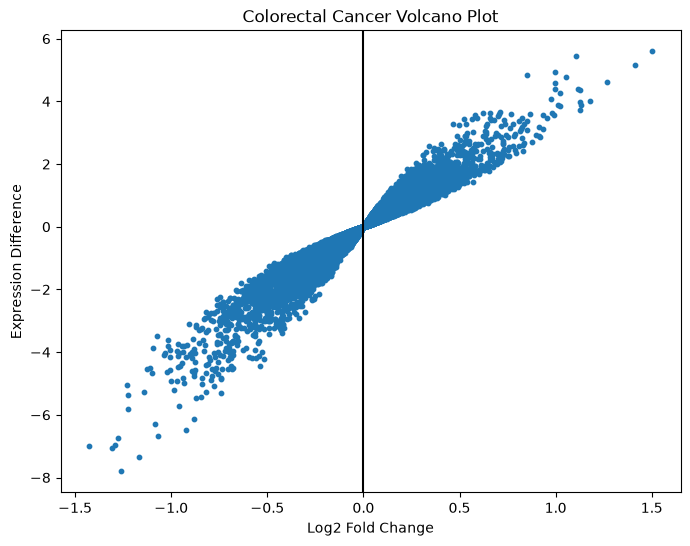

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(final_df["Log2FC"], final_df["Cancer_Mean"] - final_df["Healthy_Mean"], s=10)

plt.axvline(x=0, color="black")
plt.xlabel("Log2 Fold Change")
plt.ylabel("Expression Difference")
plt.title("Colorectal Cancer Volcano Plot")

plt.show()

In [ ]:
final_df.sort_values("Log2FC", ascending=False).head(10)

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
28930,11744030_a_at,2.046251,7.637574,1.503592,NaN
28931,11744031_at,2.090997,7.238808,1.414364,NaN
7683,11722783_at,2.281872,6.901970,1.267694,NaN
10665,11725765_a_at,2.164368,6.165965,1.179244,NaN
18607,11733707_x_at,2.254839,6.137274,1.132787,NaN
36804,11751904_x_at,2.138936,5.859596,1.127848,NaN
10666,11725766_x_at,2.352968,6.327022,1.127788,NaN
29324,11744424_a_at,2.696535,7.069122,1.126238,NaN
40974,11756074_a_at,2.759903,7.153995,1.116811,NaN
42928,11758028_s_at,3.740465,9.197886,1.105170,NaN


In [ ]:
final_df.sort_values("Log2FC", ascending=False).head(20)

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
28930,11744030_a_at,2.046251,7.637574,1.503592,NaN
28931,11744031_at,2.090997,7.238808,1.414364,NaN
7683,11722783_at,2.281872,6.901970,1.267694,NaN
10665,11725765_a_at,2.164368,6.165965,1.179244,NaN
18607,11733707_x_at,2.254839,6.137274,1.132787,NaN
36804,11751904_x_at,2.138936,5.859596,1.127848,NaN
10666,11725766_x_at,2.352968,6.327022,1.127788,NaN
29324,11744424_a_at,2.696535,7.069122,1.126238,NaN
40974,11756074_a_at,2.759903,7.153995,1.116811,NaN
42928,11758028_s_at,3.740465,9.197886,1.105170,NaN


In [ ]:
final_df.sort_values("Log2FC", ascending=True).head(20)

,Probe_ID,Healthy_Mean,Cancer_Mean,Log2FC,Gene
22194,11737294_a_at,10.137382,3.137554,-1.428560,NaN
14482,11729582_s_at,10.872593,3.803621,-1.305441,NaN
11664,11726764_at,10.755036,3.807132,-1.290031,NaN
17738,11732838_at,10.491291,3.747131,-1.275413,NaN
14483,11729583_x_at,12.390892,4.582909,-1.262163,NaN
44364,11759464_at,7.798093,2.747332,-1.231327,NaN
9438,11724538_a_at,9.180165,3.355973,-1.224694,NaN
15665,11730765_at,8.366905,3.008594,-1.224476,NaN
13671,11728771_a_at,12.241558,4.890284,-1.168664,NaN
13626,11728726_a_at,8.674647,3.392937,-1.139023,NaN


In [ ]:
final_df.to_csv("crc_differential_expression.csv", index=False)